In [20]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.integrate as integrate

from numpy import pi, exp, cos, sin, sqrt, cosh, log, tanh, arcsinh, arctanh
import tinyarray as ta

from scipy.special import j0,k0
import time

In [21]:
import os
import pickle

In [22]:
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band


In [23]:
from tqdm import tqdm_notebook # to have a progress bar for the loop

In [24]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [25]:
def Fermi_function(E,T):
    '''returns the Fermi function at energy E and temperature T
    '''
    exp_beta_E = exp(E/T)
    
    if np.isposinf(exp_beta_E):
        return 0.
    elif np.isneginf(exp_beta_E):
        return 1.
    else: 
        return 1./(1. + exp_beta_E)


## Analytic formulas

In [26]:
def critical_temperature(C):
    if C==1.0:
        return 1/4
    elif C==0.0:
        return 0.0
    elif C==2.0:
        return 0.0
    else:
        return 1/4 * (C-1)/arctanh(C-1)

In [27]:
Cs = np.linspace(0,2,1001)
Tcs = np.array([critical_temperature(C) for C in Cs])

(0, 0.27)

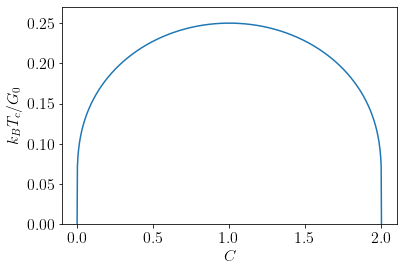

In [28]:
plt.plot(Cs, Tcs)
plt.ylabel('$k_B T_c/G_0$')
plt.xlabel('$C$')
plt.ylim(0,0.27)

## Stochastic algorithm

In [29]:
def self_consistency_solver_stochastic(mz0, mu0, T, C, G0, niter=1000, stepsize=1.0,
                                nonzero=1e-2, zero_tol=1e-5, ftol=1e-8):
    ''' Solves the superconducting mean-field equations self-consistently.
        A stochastic algorithm (Basin-hopping) is used to find the optimal Delta and mu.
        It tries to find solutions with nonzero Delta, if they exist.
           
        Parameters: Delta0: float
                        initial guess for magnetization
                    mu0: float
                        initial guess for chemical potential
                    T: float
                        positive temperature
                    C: float
                        density (0 < C < 2)
                    G0: float
                        system-specific integral that should be obtained beforehand
                    
                        
        returns: Delta, mu: floats
                    final solutions for superconducting gap and chemical potential
                 F: float
                    F(Delta,mu) at the minimum
                            
    '''
    
    from scipy.optimize import basinhopping
    from numpy.linalg import norm
    
    # reformulate self-consistency equations as a root-finding problem of 
    # functions f1 and f2, i.e., for the optimal (Delta,mu) we have that
    # f1(Delta,mu) = f2(Delta,mu) = 0
    
    def f1(Delta, mu):
        root = sqrt(Delta**2 + mu**2)
        return G0*tanh(root/T/2) - 2*root 

    def f2(Delta, mu):
        root = sqrt(Delta**2 + mu**2)
        return C - 1. - mu/root*tanh(root/T/2)
    
    # the root-finding problem is reformulated as a minimization problem
    # of the function F(Delta,mu) = f1(Delta,mu)**2 + f2(Delta,mu)**2
    
    def F(x):
        Delta, mu = x
        return f1(Delta,mu)**2 + f2(Delta,mu)**2
    
    # We are interested in possible nonzero solutions for Delta
    # However, Delta=0 is always a solution of the self-consistency equation
    # Therefore, we keep track of minima outside the interval [-nonzero, nonzero]
    # and keep the stochastic algorithm from converging to Delta=0 by only accepting 
    # solutions outside the interval [-zero_tol,zero_tol]
    
    nonzero_min = [F([Delta0,mu0]), Delta0, mu0]
    
    def accept_test(f_new, x_new, f_old, x_old):
        Delta1, mu1 = x_new
        if abs(Delta1) < zero_tol: 
            return False
        else:
            return True
    
    def callback(x, f, accept):        
        Delta, mu = x
        fmin = nonzero_min[0]
        if f < fmin and abs(Delta) > nonzero:
            nonzero_min[0] = f
            nonzero_min[1] = Delta
            nonzero_min[2] = mu
               
    x0 = [Delta0, mu0]
    results = basinhopping(F, x0, stepsize=stepsize, niter=niter, 
                           accept_test=accept_test, callback=callback)

    # If there exists a minimum (<ftol) away from Delta=0, return that one.
    # Otherwise, return the minimum with Delta=0.
           
    if nonzero_min[0] < ftol:
        return nonzero_min[1], nonzero_min[2], nonzero_min[0] # Delta, mu, F(Delta,mu)
    else:
        return results['x'][0], results['x'][0], results['fun'] # Delta, mu, F(Delta,mu)

In [30]:
def initiate(C):
    ''' Initiates (Delta,mu) with random values from a small neighborhood around the expected
        values for the given C at T=0
    '''
    sign = np.sign(np.random.random_sample()-0.5)
    
    Delta0 = sign*(0.5*sqrt(C*(2-C))*(1 + 0.1*(2*np.random.random_sample()-1))) 
    mu0 = 0.5*(C-1)*(1 + 0.1*(2*np.random.random_sample()-1))
    
    return Delta0, mu0

In [ ]:
C=0.5
G0=1.0
nT=51

Ts = np.linspace(0.01, 0.3, nT)
Deltas_1 = np.zeros(nT)
mus_1 = np.zeros(nT)
errs_1 = np.zeros(nT)

Delta0, mu0 = initiate(C)

for i,T in enumerate(Ts):
    results = self_consistency_solver_stochastic(Delta0, mu0, T, C, G0)
    Deltas_1[i] = results[0]
    mus_1[i] = results[1]
    errs_1[i] = results[2]
    
    Delta0 = Deltas_1[i]
    mu0 = mus_1[i]
    print(i, results)
    

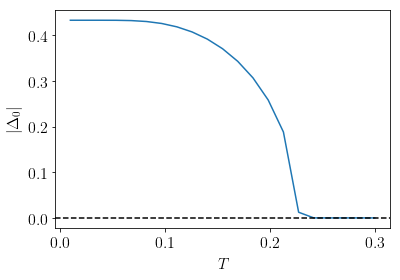

In [41]:
plt.plot(Ts,abs(Deltas_1))
#plt.ylim(-0.05,0.55)
plt.xlabel('$T$')
plt.ylabel('$|\Delta_0|$')
plt.axhline(0,ls='--',c='k')

In [31]:
import warnings
warnings.filterwarnings('ignore')

G0=1.0

nT = 51
nC = 51
Ts = np.linspace(0.001, 0.3, nT)
Cs = np.linspace(0., 2., nC)

Deltas = np.zeros((nC,nT))
mus = np.zeros((nC,nT))
errs= np.zeros((nC,nT))

counter = 1
for i,C in enumerate(Cs):
    Delta0, mu0 = initiate(C)
    for j,T in enumerate(Ts):
        print('\rcomputing phase diagram... {} of {}'.format(counter, nT*nC), end='')
        results = self_consistency_solver_stochastic(Delta0, mu0, T, C, G0)
        Deltas[i,j] = results[0]
        mus[i,j] = results[1]
        errs[i,j] = results[2]
        Delta0 = Deltas[i,j]
        mu0 = mus[i,j]
        counter += 1
        #print(i, j, results)

computing phase diagram... 2601 of 2601

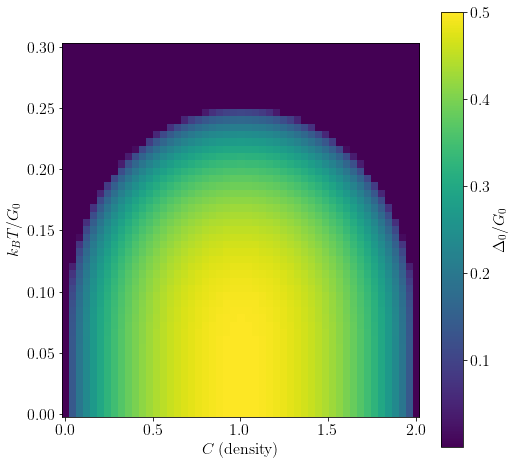

In [32]:
plt.figure(figsize=(8,8))
dT = (Ts[1]-Ts[0])/2
dC = (Cs[1]-Cs[0])/2
plt.imshow(abs(Deltas).transpose(), extent=(Cs[0]-dC,Cs[-1]+dC,Ts[0]-dT,Ts[-1]+dT), 
           aspect=7, origin='lower', interpolation='nearest')
#plt.plot(Cs, [critical_temperature(C) for C in Cs], c='red')
plt.xlabel('$C\:\mathrm{(density)}$')
plt.ylabel('$k_B T/G_0$')
plt.colorbar(label='$\Delta_0/G_0$')
#plt.ylim(0.0,0.3)

(0.0, 0.3)

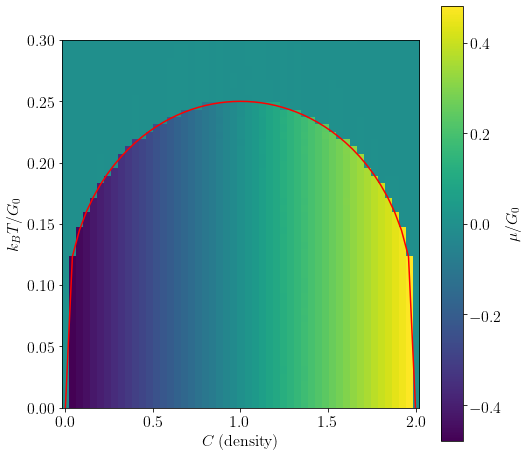

In [33]:
plt.figure(figsize=(8,8))
dT = (Ts[1]-Ts[0])/2
dC = (Cs[1]-Cs[0])/2
plt.imshow(mus.transpose(), extent=(Cs[0]-dC,Cs[-1]+dC,Ts[0]-dT,Ts[-1]+dT), 
           aspect=7, origin='lower', interpolation='nearest')
#plt.plot((1-Cs)/2, Cs, c='red')
plt.plot(Cs, [critical_temperature(C) for C in Cs], c='red')
plt.ylabel('$k_B T/G_0$')
plt.xlabel('$C\:\mathrm{(density)}$')
plt.colorbar(label='$\mu/G_0$')
plt.ylim(0.0,0.3)

In [36]:
params = dict(G0=G0)

In [37]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'superconducting_meanfield_C_T'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(params, fp)
pickle.dump(Cs, fp)
pickle.dump(Ts, fp)
pickle.dump(Deltas, fp)
pickle.dump(mus, fp)
pickle.dump(errs, fp)
#fp.close()